In [ ]:
!unzip "archive (1).zip"

Archive:  archive (1).zip
  inflating: customer_churn_data.csv  


In [ ]:
pip install imbalanced-learn --break-system-packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(f"/content/customer_churn_data.csv")

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [ ]:
df.tail()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes
999,1000,50,Male,1,56.67,Month-to-Month,NaN,56.67,No,Yes


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,297
TotalCharges,0
TechSupport,0
Churn,0


In [ ]:
df['InternetService']=df['InternetService'].fillna("unknown")

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [ ]:
numeric_columns=df.select_dtypes(include=["number"])

<Axes: >

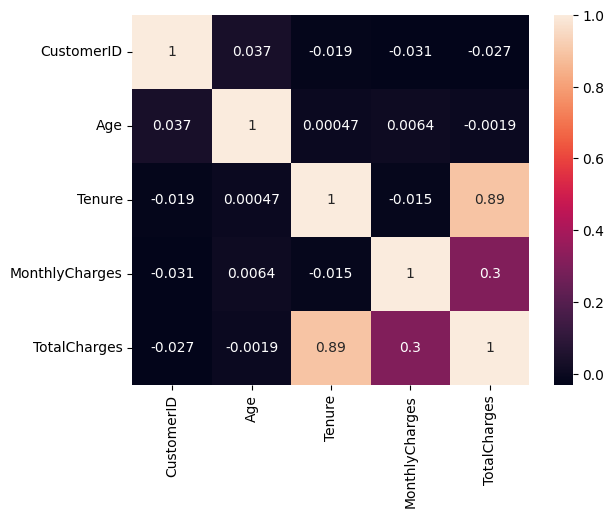

In [ ]:
sns.heatmap(numeric_columns.corr(),annot=True)

In [ ]:
df["Churn"].value_counts()

,count
Churn,
Yes,883
No,117


Text(0.5, 1.0, 'Churn (yes/no)')

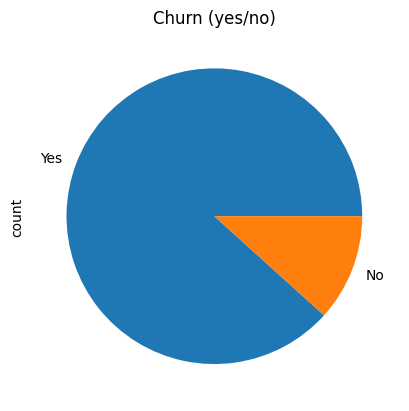

In [ ]:
df["Churn"].value_counts().plot(kind="pie")
plt.title("Churn (yes/no)")

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,62.54641
Yes,75.96077


In [ ]:
df.groupby(["Churn","Gender"])['MonthlyCharges'].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [ ]:
df.groupby("Churn")["Tenure"].mean()

,Tenure
Churn,
No,30.264957
Yes,17.476784


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Female,538
Male,462


In [ ]:
df.groupby("Churn")["Gender"].value_counts()

Churn  Gender
No     Female     68
       Male       49
Yes    Female    470
       Male      413
Name: count, dtype: int64

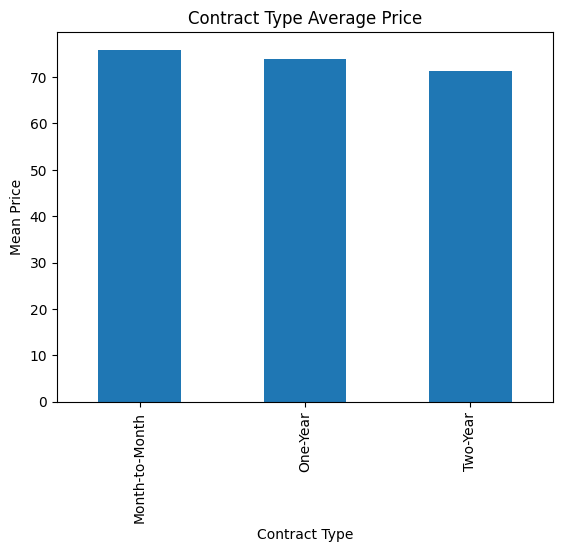

In [ ]:
df.groupby("ContractType")['MonthlyCharges'].mean().plot(kind="bar")
plt.ylabel("Mean Price")
plt.xlabel("Contract Type")
plt.title("Contract Type Average Price")
plt.show()

Text(0.5, 1.0, 'MonthlyCharges distribution')

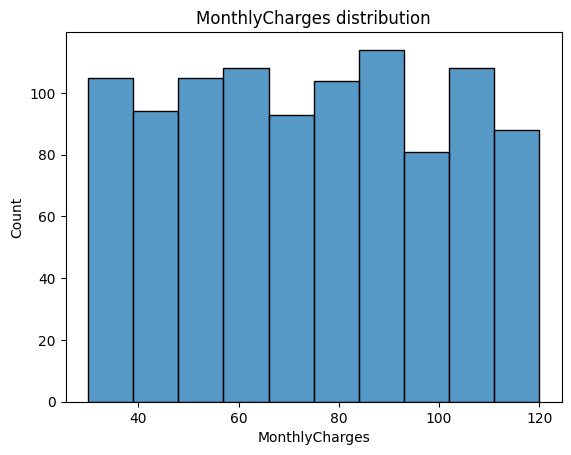

In [ ]:
sns.histplot(data=df,x="MonthlyCharges",bins=10)
plt.title("MonthlyCharges distribution")

In [ ]:
df["MonthlyCharges"].min()

30.0

In [ ]:
df["MonthlyCharges"].max()

119.96

<Axes: xlabel='Tenure', ylabel='Count'>

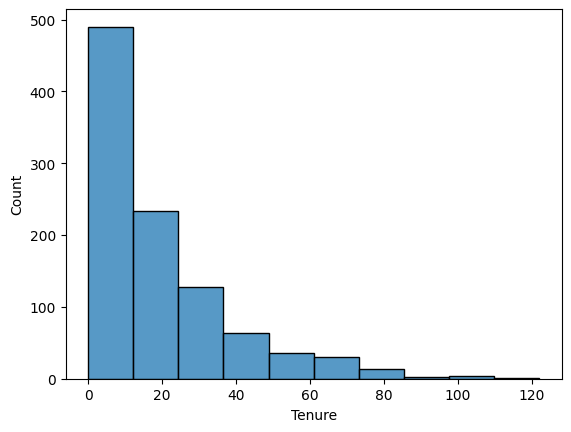

In [ ]:
sns.histplot(data=df,x="Tenure",bins=10)

In [ ]:
df["InternetService"].value_counts()

,count
InternetService,
Fiber Optic,395
DSL,308
unknown,297


In [ ]:
df.groupby(["Churn"])["InternetService"].value_counts()

Churn  InternetService
No     Fiber Optic         69
       DSL                 48
Yes    Fiber Optic        326
       unknown            297
       DSL                260
Name: count, dtype: int64

In [ ]:
df["ContractType"].unique()

array(['Month-to-Month', 'One-Year', 'Two-Year'], dtype=object)

In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [ ]:
y=df[['Churn']]
x = df[['Age', 'Gender', 'Tenure', 'MonthlyCharges','InternetService','TotalCharges',"ContractType",'TechSupport']]

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder

In [ ]:
le=LabelEncoder()
y=le.fit_transform(y)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# from sklearn.preprocessing import OneHotEncoder
# ohm=OneHotEncoder(sparse_output=False,drop="first")
# gender_Encoder_train=ohm.fit_transform(x_train[["Gender"]])
# gender_Encoder_test=ohm.transform(x_test[["Gender"]])

In [ ]:
from sklearn.compose import ColumnTransformer
transformer=ColumnTransformer(transformers=[("tnf1",OneHotEncoder(sparse_output=False,drop="first"),["Gender","InternetService",'ContractType',"TechSupport"]),
                                             ("tnf2",StandardScaler(),['Age', 'Tenure', 'MonthlyCharges','TotalCharges'])],remainder="passthrough")

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
x_train_transformed = transformer.fit_transform(x_train)
x_test_transformed = transformer.transform(x_test)

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_train_transformed.shape)

(700, 8)
(700,)
(700, 10)


In [ ]:
x_train

,Age,Gender,Tenure,MonthlyCharges,InternetService,TotalCharges,ContractType,TechSupport
541,33,Male,0,40.68,Fiber Optic,0.00,Month-to-Month,Yes
440,48,Male,94,89.57,Fiber Optic,8419.58,One-Year,No
482,28,Male,11,89.13,unknown,980.43,Month-to-Month,No
422,42,Female,37,69.85,DSL,2584.45,Month-to-Month,Yes
778,44,Female,18,91.43,Fiber Optic,1645.74,Two-Year,Yes
...,...,...,...,...,...,...,...,...
106,63,Male,10,119.90,unknown,1199.00,Month-to-Month,No
270,59,Female,5,81.69,Fiber Optic,408.45,Month-to-Month,Yes
860,47,Male,55,78.63,unknown,4324.65,Month-to-Month,No
435,45,Female,12,117.13,Fiber Optic,1405.56,Month-to-Month,Yes


In [ ]:
x

,Age,Gender,Tenure,MonthlyCharges,InternetService,TotalCharges,ContractType,TechSupport
0,49,Male,4,88.35,Fiber Optic,353.40,Month-to-Month,Yes
1,43,Male,0,36.67,Fiber Optic,0.00,Month-to-Month,Yes
2,51,Female,2,63.79,Fiber Optic,127.58,Month-to-Month,No
3,60,Female,8,102.34,DSL,818.72,One-Year,Yes
4,42,Male,32,69.01,unknown,2208.32,Month-to-Month,No
...,...,...,...,...,...,...,...,...
995,42,Male,41,37.14,Fiber Optic,1522.74,Month-to-Month,Yes
996,62,Male,9,80.93,unknown,728.37,Month-to-Month,No
997,51,Female,15,111.72,Fiber Optic,1675.80,Month-to-Month,Yes
998,39,Male,68,65.67,unknown,4465.56,One-Year,No


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [ ]:
log_model=LogisticRegression()

In [ ]:
log_model.fit(x_train_transformed,y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
y_pred=log_model.predict(x_test_transformed)

In [ ]:
accuracy_score(y_test,y_pred)

0.9433333333333334

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.92      0.62      0.74        39
         Yes       0.95      0.99      0.97       261

    accuracy                           0.94       300
   macro avg       0.93      0.80      0.85       300
weighted avg       0.94      0.94      0.94       300

[[ 24  15]
 [  2 259]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
scores=[]
scores_final=[]
for i in range(1,21,2):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train_transformed,y_train)
  y_pred_i=knn.predict(x_test_transformed)
  scores.append(accuracy_score(y_test,y_pred_i))

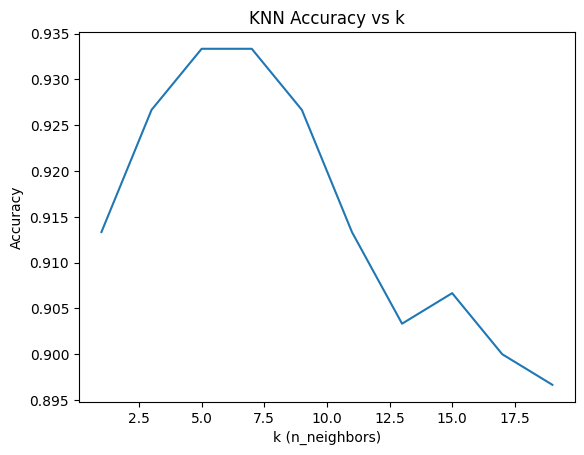

In [ ]:
plt.plot(range(1,21,2),scores)
plt.xlabel('k (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.show()

In [ ]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9,11,13,15,17,19],
    "weights": ["uniform", "distance"]
}

In [ ]:
gridkn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

In [ ]:
gridkn.fit(x_train_transformed, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19],
                         'weights': ['uniform', 'distance']})

In [ ]:
gridkn.best_params_

{'n_neighbors': 5, 'weights': 'distance'}

In [ ]:
knn_pred=gridkn.predict(x_test_transformed)

In [ ]:
accuracy_score(knn_pred,y_test)

0.9366666666666666

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, knn_pred, target_names=le.classes_))
print(confusion_matrix(y_test, knn_pred))

              precision    recall  f1-score   support

          No       0.88      0.59      0.71        39
         Yes       0.94      0.99      0.96       261

    accuracy                           0.94       300
   macro avg       0.91      0.79      0.84       300
weighted avg       0.93      0.94      0.93       300

[[ 23  16]
 [  3 258]]


In [ ]:
from sklearn.svm import SVC
svm = SVC()

In [ ]:
param_grid = {
    "C": [0.01, 0.1, 0.5, 1],
    "kernel": ["linear", "rbf", "poly"]
}

In [ ]:
gridsvc = GridSearchCV(svm, param_grid, cv=5)

In [ ]:
gridsvc.fit(x_train_transformed,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linear', 'rbf', 'poly']})

In [ ]:
gridsvc.best_params_

{'C': 1, 'kernel': 'rbf'}

In [ ]:
y_pred_svm= gridsvc.predict(x_test_transformed)

In [ ]:
accuracy_score(y_test,y_pred_svm)

0.94

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_svm, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

          No       0.92      0.59      0.72        39
         Yes       0.94      0.99      0.97       261

    accuracy                           0.94       300
   macro avg       0.93      0.79      0.84       300
weighted avg       0.94      0.94      0.93       300

[[ 23  16]
 [  2 259]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
grid_tree = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5
)

In [ ]:
grid_tree.fit(x_train_transformed, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [ ]:
print(grid_tree.best_params_)
print(grid_tree.best_score_)

{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
0.99


In [ ]:
y_pred_tree=grid_tree.predict(x_test_transformed)

In [ ]:
accuracy_score(y_test,y_pred_tree)

0.9966666666666667

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_tree, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred_tree))

              precision    recall  f1-score   support

          No       0.97      1.00      0.99        39
         Yes       1.00      1.00      1.00       261

    accuracy                           1.00       300
   macro avg       0.99      1.00      0.99       300
weighted avg       1.00      1.00      1.00       300

[[ 39   0]
 [  1 260]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()

In [ ]:
param_grid = {
    "n_estimators": [32, 64, 128, 256],
    "max_features": [2, 3, 4],
    "bootstrap": [True, False]
}

In [ ]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv=5)
grid_rfc.fit(x_train_transformed, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [ ]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 3, 'n_estimators': 256}

In [ ]:
y_pred_rfc= grid_rfc.predict(x_test_transformed)

In [ ]:
accuracy_score(y_test,y_pred_rfc)

0.9966666666666667

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_rfc, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

          No       1.00      0.97      0.99        39
         Yes       1.00      1.00      1.00       261

    accuracy                           1.00       300
   macro avg       1.00      0.99      0.99       300
weighted avg       1.00      1.00      1.00       300

[[ 24  15]
 [  2 259]]


In [ ]:
best_model=grid_rfc.best_estimator_

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline

In [ ]:
pipe_random_forest= Pipeline([
     ("preprocessor", transformer),
     ("model",best_model),
 ])

In [ ]:
pipe_random_forest.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Gender', 'InternetService',
                                                   'ContractType',
                                                   'TechSupport']),
                                                 ('tnf2', StandardScaler(),
                                                  ['Age', 'Tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model',
                 RandomForestClassifier(max_features=3, n_estimators=256))])

In [ ]:
best_model_svm=gridsvc.best_estimator_

In [ ]:
pipe_svm=Pipeline([
    ("preprocessor",transformer),
 ("model_Svm",best_model_svm)
 ])

In [ ]:
pipe_svm.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Gender', 'InternetService',
                                                   'ContractType',
                                                   'TechSupport']),
                                                 ('tnf2', StandardScaler(),
                                                  ['Age', 'Tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model_Svm', SVC(C=1))])

In [ ]:
best_model_DT=grid_tree.best_estimator_

In [ ]:
pipe_DT=Pipeline([
    ("preprocessor",transformer),
     ("model_DT",best_model_DT)
     ])

In [ ]:
pipe_DT.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Gender', 'InternetService',
                                                   'ContractType',
                                                   'TechSupport']),
                                                 ('tnf2', StandardScaler(),
                                                  ['Age', 'Tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model_DT', DecisionTreeClassifier())])

In [ ]:
import joblib

In [ ]:
joblib.dump(pipe_random_forest, "random_forest_pipeline.pkl")

['random_forest_pipeline.pkl']

In [ ]:
joblib.dump(pipe_DT, "decision_Tree_pipeline.pkl")

['decision_Tree_pipeline.pkl']

In [ ]:
joblib.dump(pipe_svm, "SVM_pipeline.pkl")

['SVM_pipeline.pkl']